Set up dataset construction parameters

In [4]:
from utils.image_processing import sitk_load
import json
import os
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

CONFIG = {
    "database_path": "../CAMUS/database_nifti",
    "output_path": "../Dataset/CAMUS/Landmarks_3_10",
    "scale_factor": 0.10, # 10% of the original average contour size
    "resolutions": ["full", "half", "quarter"], # Names are only for reference
    # "resolutions": [1, 1/2, 1/4], # Actual scale factors
    "image_types": ["2CH", "4CH"],  
    "organs": ["1", "2", "3"], # ID in the mask
    "organ_names": ["LV Endo", "LV Epi", "LA"], # Name ID
    "inputsize": 512,
    "flip_h": True,
    "flip_v": False,
    "rotate": True,
    "transpose": False
}

os.makedirs(CONFIG["output_path"], exist_ok=True)
with open(os.path.join(CONFIG["output_path"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=4)

First, we organize the dataset in folders:

images/ ...

masks/ ...

This reorganization is not required if the masks are provided in a file, with a list of paths.

In [ ]:
def process_and_save_images(array, image_path, general_dir):
    paths = []

    for i, image in enumerate(array):
        output_file = image_path / f"{i}.png"
        if not output_file.exists():
            cv2.imwrite(str(output_file), image)
        if not output_file.exists():
            print(f"Warning: Failed to save image {output_file}")
        else:
            paths.append(str(output_file.relative_to(general_dir)))
    
    return paths

def organize_dataset(config):
    """
    Organizes the dataset into images and masks folders and creates a file list.
    
    Args:
    config (dict): Configuration dictionary containing paths and other settings.
    
    Returns:
    tuple: (image_list_path, mask_list_path)
    """
    image_dir = Path(config['output_path']) / 'images'
    mask_dir = Path(config['output_path']) / 'masks'
    image_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)
    
    image_list = []
    mask_list = []
    
    # This part will need to be adapted for each specific dataset
    for patient in Path(config['database_path']).iterdir():
        for img_type in config['image_types']:
            image_path = patient / f"{patient.name}_{img_type}_half_sequence.nii.gz"
            mask_path = Path(str(image_path).replace(".nii.gz", "_gt.nii.gz"))
            
            # Copy or link files to new locations
            new_image_path = image_dir / patient.name / img_type 
            new_mask_path = mask_dir / patient.name / img_type 
                        
            image_array, _ = sitk_load(image_path)
            mask_array, _ = sitk_load(mask_path)
            
            os.makedirs(new_image_path, exist_ok=True)
            os.makedirs(new_mask_path, exist_ok=True)
            
            image_list_internal = process_and_save_images(image_array, new_image_path, image_dir)
            mask_list_internal = process_and_save_images(mask_array, new_mask_path, mask_dir)

            image_list.extend(image_list_internal)
            mask_list.extend(mask_list_internal)
    
    # Write file lists
    image_list_path = Path(config['output_path']) / 'image_list.txt'
    mask_list_path = Path(config['output_path']) / 'mask_list.txt'
    
    with open(image_list_path, 'w') as f:
        f.write('\n'.join(image_list))
    with open(mask_list_path, 'w') as f:
        f.write('\n'.join(mask_list))
    
    return

In [3]:
# Step 1: Organize dataset
organize_dataset(CONFIG)

Skipping patient0027 for 2CH as it already exists.
Skipping patient0027 for 4CH as it already exists.
Skipping patient0304 for 2CH as it already exists.
Skipping patient0304 for 4CH as it already exists.
Skipping patient0215 for 2CH as it already exists.
Skipping patient0215 for 4CH as it already exists.
Skipping patient0456 for 2CH as it already exists.
Skipping patient0456 for 4CH as it already exists.
Skipping patient0437 for 2CH as it already exists.
Skipping patient0437 for 4CH as it already exists.
Skipping patient0024 for 2CH as it already exists.
Skipping patient0024 for 4CH as it already exists.
Skipping patient0196 for 2CH as it already exists.
Skipping patient0196 for 4CH as it already exists.
Skipping patient0399 for 2CH as it already exists.
Skipping patient0399 for 4CH as it already exists.
Skipping patient0235 for 2CH as it already exists.
Skipping patient0235 for 4CH as it already exists.
Skipping patient0134 for 2CH as it already exists.
Skipping patient0134 for 4CH as

Then the landmarks can be directly generated from the masks.

In [5]:
from utils.image_processing import generate_landmark_contours

# Step 2: Generate landmark contours
generate_landmark_contours(CONFIG)

Loading image list from ../Dataset/CAMUS/Landmarks_2_10/image_list.txt
Loading mask list from ../Dataset/CAMUS/Landmarks_2_10/mask_list.txt
Generating landmarks for 19232 images.


'../Dataset/CAMUS/Landmarks_2_10/landmarks'

In [6]:
from utils.image_processing import get_contour_lengths

# Step 3: Get contour lengths
contour_lengths = get_contour_lengths(CONFIG, os.path.join(CONFIG["output_path"], "landmarks"))

Contour lengths:
Organ 1: min=354, max=909, avg=588.92
Organ 2: min=827, max=1826, avg=1227.43
Organ 3: min=141, max=745, avg=428.86


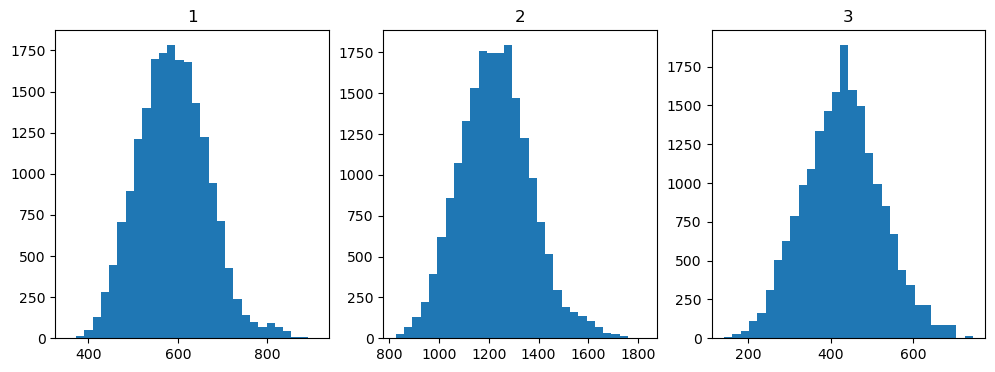

In [7]:
print("Contour lengths:")
for organ, lengths in contour_lengths.items():
    print(f"Organ {organ}: min={min(lengths)}, max={max(lengths)}, avg={sum(lengths)/len(lengths):.2f}")

plt.figure(figsize=(12, 4))

for i, j in enumerate(contour_lengths.keys()):
    plt.subplot(1, 3, i+1)
    plt.hist(contour_lengths[j], bins=30)
    plt.title(j)

In [2]:
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


(np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(1.0))
(np.float64(0.0), np.float64(1.0), np.float64(0.9531223422015865), np.float64(1.0))
(np.float64(1.0), np.float64(0.0), np.float64(0.09375), np.float64(1.0))


/tmp/ipykernel_229918/1954405105.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


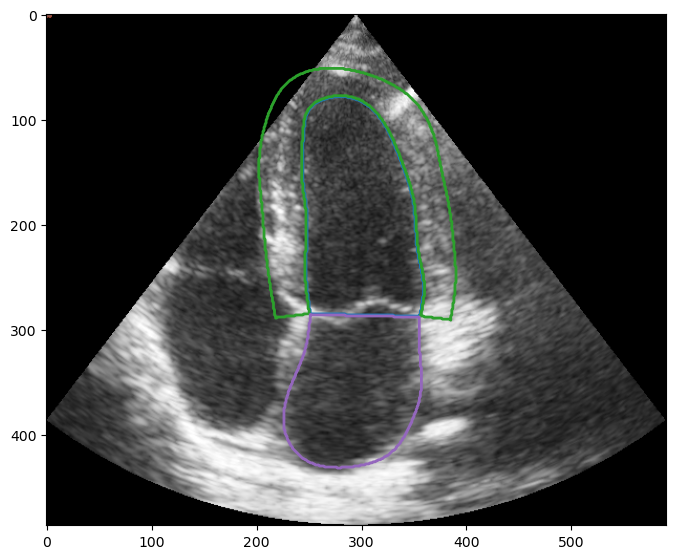

In [5]:
image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

image_path = Path(CONFIG['output_path']) / 'images' / image_list[253]
mask_path = Path(CONFIG['output_path']) / 'masks' / image_list[253]
landmarks_path = Path(CONFIG['output_path']) / 'landmarks' / Path(image_list[253]).with_suffix('.json')

image = cv2.imread(str(image_path))
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
landmarks = json.load(open(landmarks_path))

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(landmarks.items()):
    color = colors(i)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], color, lw=2)
    print(color)

The following code generates the required adjacency matrixes to run the code, from the dictionary of contour lengths.

In [8]:
# force reload the package, with one line
import importlib
import utils.matrix_ops
importlib.reload(utils.matrix_ops)

from utils.matrix_ops import generate_adjacency_matrices, save_matrices, create_sampling_matrix, generate_edge_info

adjacency_matrices, downsampling_matrices, upsampling_matrices = generate_adjacency_matrices(contour_lengths, CONFIG)

os.makedirs(f"{CONFIG['output_path']}/Independent", exist_ok=True)

for res in CONFIG["resolutions"]:
    save_matrices(adjacency_matrices[res], res, CONFIG)

for name, matrices in downsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/Independent/downsampling_{name}.npy", block_matrix)

for name, matrices in upsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/Independent/upsampling_{name}.npy", block_matrix)

generate_edge_info(CONFIG)

Organ 1 - Contour len mean: 588.9212770382695 - Atlas contour size: 64
Adjacency matrices sizes: [('full', 64), ('half', 32), ('quarter', 16)]
Downsampling matrices sizes: [('to_half', 32), ('to_quarter', 16)]
Organ 2 - Contour len mean: 1227.4308964226288 - Atlas contour size: 124
Adjacency matrices sizes: [('full', 124), ('half', 62), ('quarter', 31)]
Downsampling matrices sizes: [('to_half', 62), ('to_quarter', 31)]
Organ 3 - Contour len mean: 428.8573211314476 - Atlas contour size: 64
Adjacency matrices sizes: [('full', 64), ('half', 32), ('quarter', 16)]
Downsampling matrices sizes: [('to_half', 32), ('to_quarter', 16)]


Separate splits in training, validation and test

In [5]:
# Load the files .txt and separate them in training validation and test. Use a 80 - 10 - 10 split
import numpy as np
import random

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'

with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()
    
# samples should be taking without putting the same patient in different sets
# the list contains files in the format patient/type/image.png
# so first separate the files by patient

patients = {}
for image in image_list:
    patient = image.split('/')[0]
    if patient not in patients:
        patients[patient] = []
    patients[patient].append(image)

# now we have a dictionary with the patient as key and a list of images as value
# we can now split the patients in training, validation and test
# we will use a 80 - 10 - 10 split

n_patients = len(patients)
n_train = int(0.8 * n_patients)
n_test = int(0.1 * n_patients)
n_val = n_patients - n_train - n_test

random.seed(42)
patients = list(patients.items())
random.shuffle(patients)

train_patients = patients[:n_train]
val_patients = patients[n_train:n_train+n_val]
test_patients = patients[n_train+n_val:]

train_images = []
val_images = []
test_images = []

for patient, images in train_patients:
    train_images.extend(images)
for patient, images in val_patients:
    val_images.extend(images)
for patient, images in test_patients:
    test_images.extend(images)

# save as txt

train_image_list_path = Path(CONFIG['output_path']) / 'train.txt'
val_image_list_path = Path(CONFIG['output_path']) / 'val.txt'
test_image_list_path = Path(CONFIG['output_path']) / 'test.txt'

with open(train_image_list_path, 'w') as f:
    f.write('\n'.join(train_images))
with open(val_image_list_path, 'w') as f:
    f.write('\n'.join(val_images))
with open(test_image_list_path, 'w') as f:
    f.write('\n'.join(test_images))

### Pseudo-atlas

Atlas landmarks shape: (252, 2)


/tmp/ipykernel_1555584/3080356978.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


True

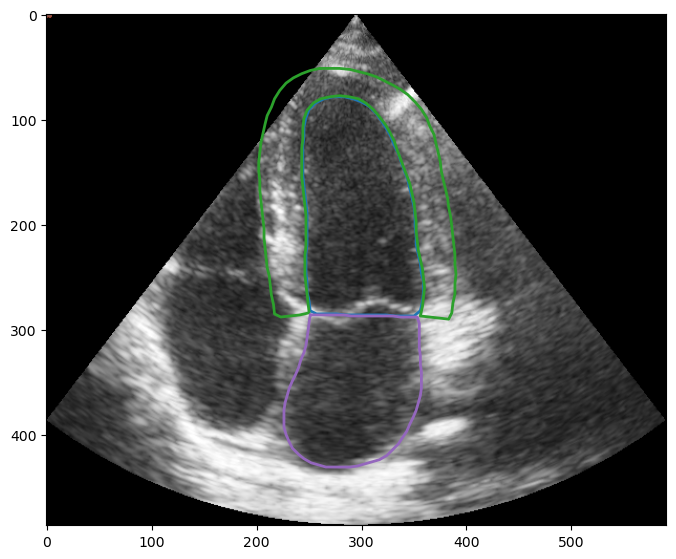

In [12]:
def interpolate_contour_linear(contour, n_points):
    """
    Interpolate contour to fixed number of points using linear interpolation.
    
    Args:
        contour: OpenCV contour (numpy array of shape (N, 1, 2))
        n_points: Target number of points
    
    Returns:
        Interpolated contour with n_points
    """
    # Reshape contour to (N, 2)
    contour = contour.reshape(-1, 2)
    
    # Calculate cumulative distances along the contour
    distances = np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1))
    cumulative_distances = np.concatenate([[0], np.cumsum(distances)])
    
    # Create uniform sampling points
    total_length = cumulative_distances[-1]
    uniform_distances = np.linspace(0, total_length, n_points)
    
    # Interpolate x and y coordinates
    x_interp = np.interp(uniform_distances, cumulative_distances, contour[:, 0])
    y_interp = np.interp(uniform_distances, cumulative_distances, contour[:, 1])
    
    # Reshape back to OpenCV format
    interpolated_contour = np.column_stack([x_interp, y_interp])
    return interpolated_contour.reshape(-1, 1, 2).astype(np.int32)

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

image_path = Path(CONFIG['output_path']) / 'images' / image_list[253]
mask_path = Path(CONFIG['output_path']) / 'masks' / image_list[253]

image = cv2.imread(str(image_path))
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

atlas_landmarks = {}

for organ in CONFIG['organs']:
    organ_mask = (mask == int(organ)).astype(np.uint8)
    contours, _ = cv2.findContours(organ_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    # approximate the contour to reduce the number of points to a fixed size,
    # 60 for first organ, 124 for second and 44 for third
    approx_size = adjacency_matrices['full'][organ].shape[0]
    
    if contours:
        contour = contours[0]
        interpolated_contour = interpolate_contour_linear(contour, approx_size)
        atlas_landmarks[CONFIG['organ_names'][int(organ) - 1]] = interpolated_contour.reshape(-1, 2).tolist()
        
plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(atlas_landmarks.items()):
    color = colors(i)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], color, lw=2)

atlas_array = []
# save the atlas landmarks as an array using the same order as the adjacency matrices
for organ in CONFIG['organs']:
    organ_name = CONFIG['organ_names'][int(organ) - 1]
    if organ_name in atlas_landmarks:
        atlas_array.append(np.array(atlas_landmarks[organ_name]))
    else:
        print(f"Warning: {organ_name} not found in atlas landmarks")

#concatenate
atlas_landmarks = np.concatenate(atlas_array, axis=0)
print("Atlas landmarks shape:", atlas_landmarks.shape)

# now save the atlas landmarks to a npy file
atlas_landmarks_path = Path(CONFIG['output_path']) / 'Independent/atlas_pos.npy'
np.save(atlas_landmarks_path, atlas_landmarks)
# and save the image
cv2.imwrite(str(Path(CONFIG['output_path']) / 'Independent/atlas_image.png'), image)